# Regression - Example demonstrating main principles that always repeat (in one form or another)

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import root_mean_squared_error

## Loading Data

In [39]:
# Create a toy regression dataset
X, y = make_regression(n_samples=1000, n_features=5, noise=20, random_state=42)

In [40]:
df = pd.DataFrame(X, columns=[f"Feature_{i}" for i in range(X.shape[1])])
df["Target"] = y

In [41]:
df.head()

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Target
0,2.056544,0.606851,0.482688,-1.130888,0.420094,66.595254
1,-0.799192,-0.645964,-0.182896,-0.482744,1.374876,-61.659436
2,1.076007,-0.796026,-0.751969,0.021312,-0.319054,-49.947499
3,-0.103255,-0.828497,1.489863,-1.643189,-1.600904,-79.939739
4,-2.063403,0.503252,-0.645572,-0.317350,-1.661083,-80.651266


## Train, Validation, and Test Set

In [42]:
X = df.drop(columns=["Target"])
y = df["Target"]

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.3, random_state=36)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (560, 5)
Validation size: (240, 5)
Test size: (200, 5)


## EDA

Text(0.5, 1.0, 'Distribution of Target Variable')

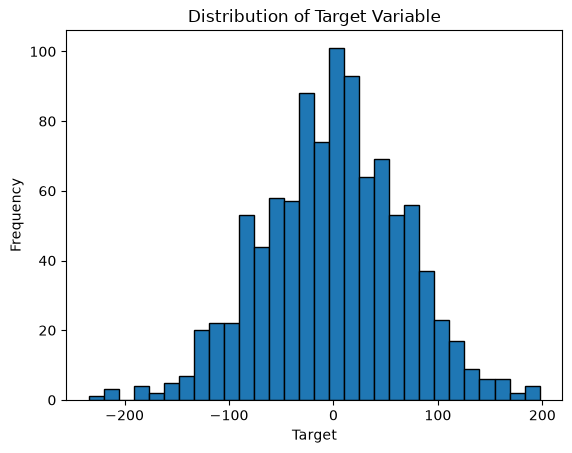

In [7]:
plt.hist(y, bins=30, edgecolor="black")
plt.xlabel("Target")
plt.ylabel("Frequency")
plt.title("Distribution of Target Variable")

In [8]:
corr = df.corr(numeric_only=True)["Target"].sort_values(ascending=False)
print("Correlation with target:\n", corr)

Correlation with target:
 Target       1.000000
Feature_1    0.695540
Feature_0    0.376001
Feature_3    0.357873
Feature_4    0.285183
Feature_2    0.279431
Name: Target, dtype: float64


class sklearn.linear_model.Ridge(alpha=1.0, *, fit_intercept=True, copy_X=True, max_iter=None, tol=0.0001, solver='auto', positive=False, random_state=None)

## Training models

In [46]:
# Linear regression
from sklearn.linear_model import Ridge


lin_reg = LinearRegression()
Ridge_reg = Ridge(alpha = 0.5)
lin_reg.fit(X_train, y_train)
Ridge_reg.fit(X_train, y_train)
lin_reg_pred = lin_reg.predict(X_val)
Ridge_reg_pred = Ridge_reg.predict(X_val)
# Decision tree
tree_reg = DecisionTreeRegressor(random_state=42)
hyperparams = {
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

tree_reg_gs = GridSearchCV(tree_reg, hyperparams, scoring="neg_mean_squared_error", cv=5, n_jobs=-1)
tree_reg_gs.fit(X_train, y_train)

tree_reg_gs_pred = tree_reg_gs.predict(X_val) 

In [50]:
Ridge_reg1 = Ridge(random_state =42)
hyperparams = {
    "alpha" :[0.1,0.5,0.7,0.9,1,5,7,9]
}

Ridge_reg_gs1 = GridSearchCV(Ridge_reg1, hyperparams, scoring="neg_mean_squared_error", cv=5, n_jobs=-1)
Ridge_reg_gs1.fit(X_train, y_train)
print(Ridge_reg_gs1.best_params_)

{'alpha': 0.5}


class sklearn.ensemble.RandomForestClassifier(n_estimators=100, *, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, class_weight=None, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)

In [27]:
random_forest_reg = RandomForestRegressor(random_state =42)
hyperparams = {
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

random_forest_reg_gs = GridSearchCV(random_forest_reg, hyperparams, scoring="neg_mean_squared_error", cv=5, n_jobs=-1)
random_forest_reg_gs.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose:

In [30]:
random_forest_reg_gs_pred = random_forest_reg_gs.predict(X_val) 

In [31]:
print(tree_reg_gs.best_params_)
pd.DataFrame(tree_reg_gs.cv_results_)

{'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003869,0.000307,0.002430,0.000315,3,1,2,"{'max_depth': 3, 'min_samples_leaf': 1, 'min_s...",-2595.629465,-2942.897296,-2544.555518,-2488.157700,-2529.219784,-2620.091952,165.028394,28
1,0.004162,0.000338,0.002802,0.000203,3,1,5,"{'max_depth': 3, 'min_samples_leaf': 1, 'min_s...",-2595.629465,-2942.897296,-2544.555518,-2488.157700,-2529.219784,-2620.091952,165.028394,28
2,0.004081,0.000627,0.002395,0.000751,3,1,10,"{'max_depth': 3, 'min_samples_leaf': 1, 'min_s...",-2595.629465,-2942.897296,-2544.555518,-2488.157700,-2529.219784,-2620.091952,165.028394,28
3,0.003473,0.000955,0.002021,0.000533,3,2,2,"{'max_depth': 3, 'min_samples_leaf': 2, 'min_s...",-2595.629465,-2942.897296,-2544.555518,-2488.157700,-2529.219784,-2620.091952,165.028394,28
4,0.003402,0.000861,0.001589,0.000412,3,2,5,"{'max_depth': 3, 'min_samples_leaf': 2, 'min_s...",-2595.629465,-2942.897296,-2544.555518,-2488.157700,-2529.219784,-2620.091952,165.028394,28
5,0.002762,0.000894,0.001581,0.000491,3,2,10,"{'max_depth': 3, 'min_samples_leaf': 2, 'min_s...",-2595.629465,-2942.897296,-2544.555518,-2488.157700,-2529.219784,-2620.091952,165.028394,28
6,0.002846,0.000489,0.001566,0.000473,3,4,2,"{'max_depth': 3, 'min_samples_leaf': 4, 'min_s...",-2595.629465,-2942.897296,-2544.555518,-2488.157700,-2529.219784,-2620.091952,165.028394,28
7,0.004085,0.000397,0.002555,0.000358,3,4,5,"{'max_depth': 3, 'min_samples_leaf': 4, 'min_s...",-2595.629465,-2942.897296,-2544.555518,-2488.157700,-2529.219784,-2620.091952,165.028394,28
8,0.003713,0.000486,0.002191,0.000369,3,4,10,"{'max_depth': 3, 'min_samples_leaf': 4, 'min_s...",-2595.629465,-2942.897296,-2544.555518,-2488.157700,-2529.219784,-2620.091952,165.028394,28
9,0.003538,0.000488,0.001957,0.000441,5,1,2,"{'max_depth': 5, 'min_samples_leaf': 1, 'min_s...",-2078.649277,-2150.396377,-1867.790434,-2192.270554,-2325.157225,-2122.852774,150.675357,25


In [24]:
print(random_forest_reg_gs.best_params_)

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [32]:
pd.DataFrame(random_forest_reg_gs.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.385361,0.042790,0.028981,0.012052,3,1,2,"{'max_depth': 3, 'min_samples_leaf': 1, 'min_s...",-1907.254687,-1763.566511,-1623.899024,-1490.102347,-2130.077462,-1782.980006,222.432824,35
1,0.328455,0.009808,0.020400,0.003438,3,1,5,"{'max_depth': 3, 'min_samples_leaf': 1, 'min_s...",-1907.254687,-1763.566511,-1623.924036,-1490.102347,-2129.763277,-1782.922172,222.331206,34
2,0.281111,0.084026,0.019333,0.006361,3,1,10,"{'max_depth': 3, 'min_samples_leaf': 1, 'min_s...",-1907.644345,-1763.566511,-1623.924036,-1490.102347,-2129.763277,-1783.000103,222.374837,36
3,0.235954,0.027685,0.015762,0.001323,3,2,2,"{'max_depth': 3, 'min_samples_leaf': 2, 'min_s...",-1904.740635,-1765.599870,-1622.564285,-1490.707583,-2123.320627,-1781.386600,220.046875,31
4,0.245244,0.040075,0.014698,0.001709,3,2,5,"{'max_depth': 3, 'min_samples_leaf': 2, 'min_s...",-1904.740635,-1765.599870,-1622.564285,-1490.707583,-2123.320627,-1781.386600,220.046875,31
5,0.211265,0.009669,0.016530,0.001889,3,2,10,"{'max_depth': 3, 'min_samples_leaf': 2, 'min_s...",-1905.131750,-1765.599870,-1622.564285,-1490.707583,-2123.320627,-1781.464823,220.090777,33
6,0.258698,0.045199,0.016812,0.001769,3,4,2,"{'max_depth': 3, 'min_samples_leaf': 4, 'min_s...",-1908.730867,-1755.637866,-1602.763641,-1493.100863,-2110.767228,-1774.200093,219.147328,28
7,0.216154,0.025678,0.014967,0.001373,3,4,5,"{'max_depth': 3, 'min_samples_leaf': 4, 'min_s...",-1908.730867,-1755.637866,-1602.763641,-1493.100863,-2110.767228,-1774.200093,219.147328,28
8,0.209953,0.004007,0.015605,0.001460,3,4,10,"{'max_depth': 3, 'min_samples_leaf': 4, 'min_s...",-1908.730867,-1755.637866,-1602.763641,-1493.100863,-2110.767228,-1774.200093,219.147328,28
9,0.279867,0.043545,0.017508,0.004738,5,1,2,"{'max_depth': 5, 'min_samples_leaf': 1, 'min_s...",-1227.991102,-1280.037471,-1056.871387,-996.416508,-1514.549086,-1215.173111,182.708263,26


In [47]:
lr_rmse = root_mean_squared_error(lin_reg_pred, y_val)
tree_rmse = root_mean_squared_error(tree_reg_gs_pred, y_val)
random_forest_rmse = root_mean_squared_error(random_forest_reg_gs_pred, y_val)
Ridge_rmse = root_mean_squared_error(Ridge_reg_pred, y_val)

print("RMSE LR:", lr_rmse, "\nRMSE Tree:", tree_rmse)
print("RandomForestRegressor Rmse:", random_forest_rmse)
print("Ridge Regression Rmse:", Ridge_rmse)

RMSE LR: 20.72524396702146 
RMSE Tree: 41.18026776055872
RandomForestRegressor Rmse: 28.050498297833027
Ridge Regression Rmse: 20.718980110137352


## Evaluation on test data

In [12]:
lr_final = lin_reg.fit(X_train_val, y_train_val)

In [13]:
lr_test_pred = lr_final.predict(X_test)

lr_rmse_test = root_mean_squared_error(lr_test_pred, y_test)
print(lr_rmse_test)

20.505749184566383


## Retraining the model on all data and saving it

In [14]:
lr_finished = lin_reg.fit(X, y)

In [15]:
import joblib

In [16]:
joblib.dump(lr_finished, 'lr_finished.pkl')
print("Model saved!")
loaded_model = joblib.load('lr_finished.pkl')
print("Model loaded!")

Model saved!
Model loaded!


In [17]:
predictions = loaded_model.predict(X_test.iloc[:5, :])
print(predictions)
print(y_test.iloc[:5])


[ 92.36333777  48.04244782 -87.03395226 -28.83554399  84.49223751]
204    102.987469
71      47.091028
594   -105.747326
672    -21.903111
14     116.131344
Name: Target, dtype: float64


## Questions
1. Explain what the code does. What are the main steps?
2. What does this code do?
   
print(tree_reg_gs.best_params_)

pd.DataFrame(tree_reg_gs.cv_results_)

3. Try to add a third model (example, random forest) in the modelling flow.